# Analysis

## Load GeoTIFFs

In [1]:
import rasterio
import numpy as np

def load_band(path: str):
    with rasterio.open(path) as src:
        band = src.read(1).astype(float)
        meta = src.meta.copy()
    band[band == 0] = np.nan
    band /= 10000.0
    return band, meta

In [2]:
pre_nir,   meta = load_band("data/processed/pre_nir.tif")
pre_swir,  _    = load_band("data/processed/pre_swir.tif")
post_nir,  _    = load_band("data/processed/post_nir.tif")
post_swir, _    = load_band("data/processed/post_swir.tif")

In [ ]:
assert pre_nir.shape == pre_swir.shape == post_nir.shape == post_swir.shape, (
    "Pre/post band shapes don't match -- check AOI clipping and scene grids in notebook 02"
)

## NBR and dNBR

The actual NBR and dNBR functions are simple, it just requires the NIR and SWIR bands to get a result

In [9]:
pre_NBR = (pre_nir - pre_swir) / (pre_nir + pre_swir)
post_NBR = (post_nir - post_swir) / (post_nir + post_swir)

dNBR = pre_NBR - post_NBR

RdNBR normalizes dNBR by pre-fire vegetation vigor, which corrects for the fact that sparsely-vegetated areas produce a smaller raw dNBR for the same relative loss. Published RdNBR severity breakpoints are usually calibrated per study area, so it's shown below as a supplementary comparison layer; classification uses dNBR's more standard, portable thresholds.

In [ ]:
# Avoid divide-by-zero / sqrt-of-negative for pixels with near-zero or negative pre-fire NBR
denom = np.sqrt(np.abs(pre_NBR))
RdNBR = np.where(denom > 1e-6, dNBR / denom, np.nan)

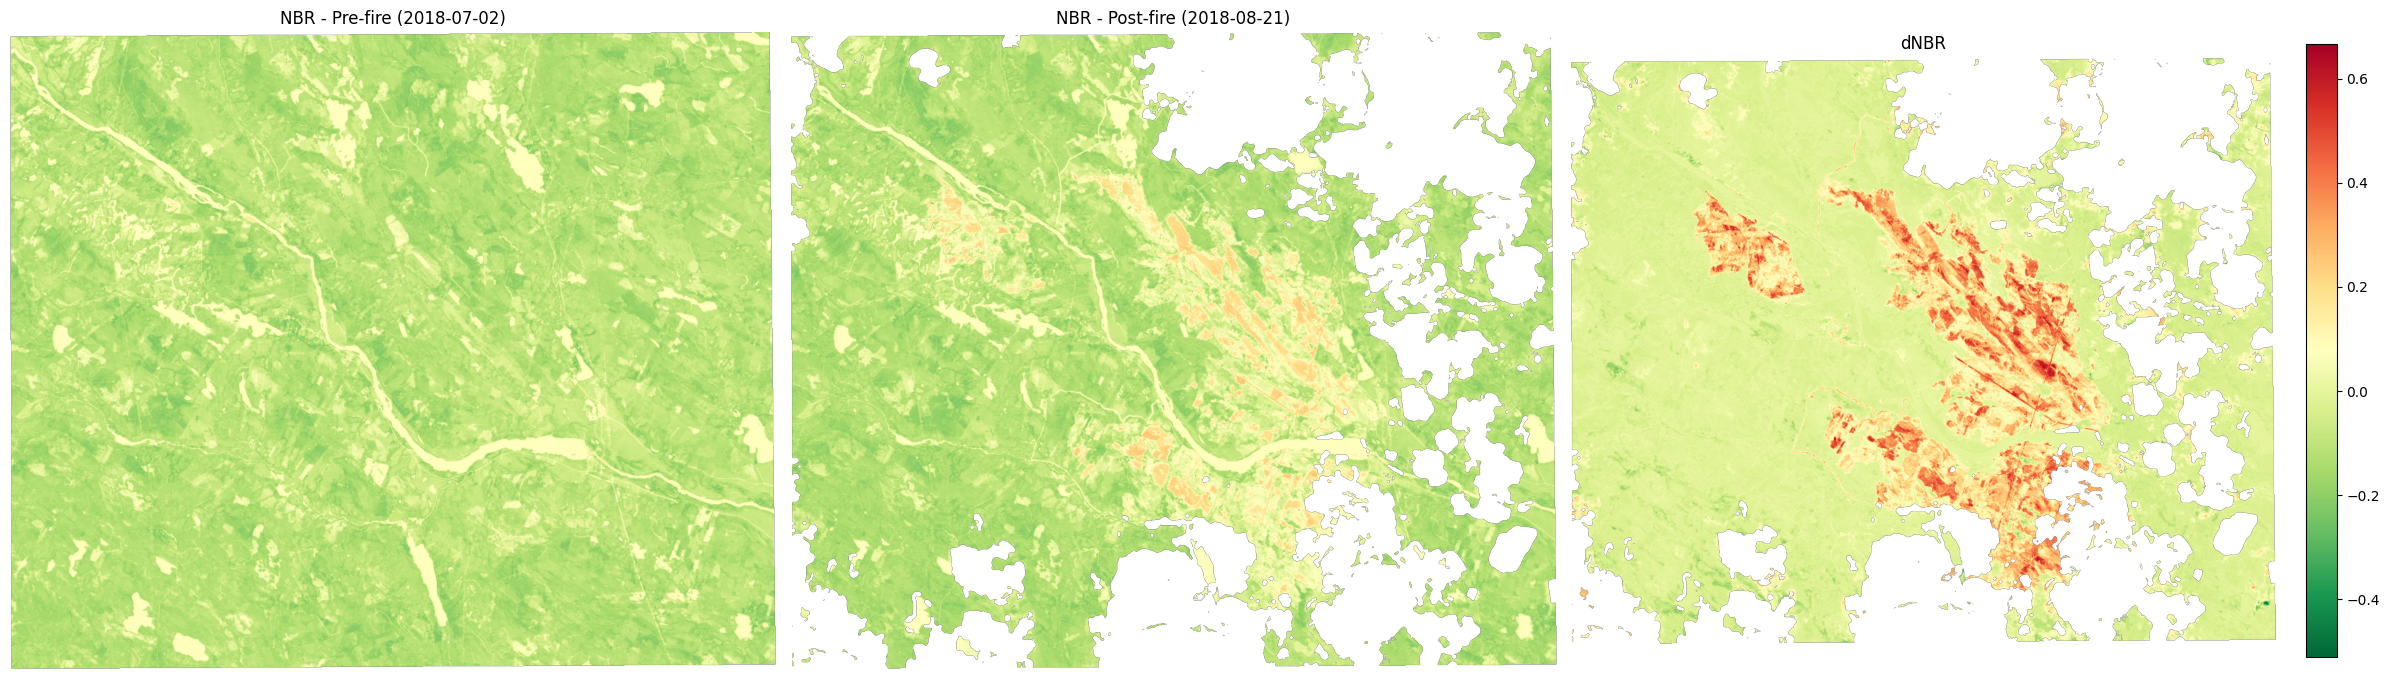

In [39]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(24, 8))

axes[0].imshow(pre_NBR, cmap="RdYlGn", vmin=-1, vmax=1)
axes[0].set_title("NBR - Pre-fire (2018-07-02)")
axes[0].axis("off")

axes[1].imshow(post_NBR, cmap="RdYlGn", vmin=-1, vmax=1)
axes[1].set_title("NBR - Post-fire (2018-08-21)")
axes[1].axis("off")

im = axes[2].imshow(dNBR, cmap="RdYlGn_r")
axes[2].set_title("dNBR")
axes[2].axis("off")
fig.colorbar(im, ax=axes[2], fraction=0.04, pad=0.04)

plt.tight_layout()
plt.savefig("data/processed/nbr_comparison.png", bbox_inches="tight")
plt.show()

## Burn Severity Classification

Binning dNBR into discrete severity classes using the standard USGS/FIREMON breakpoints (unscaled NBR units, i.e. not multiplied by 1000):

| dNBR range | Class |
|---|---|
| < 0.10 | Unburned |
| 0.10 – 0.27 | Low severity |
| 0.27 – 0.44 | Moderate-low severity |
| 0.44 – 0.66 | Moderate-high severity |
| > 0.66 | High severity |

These are literature-standard starting points, not calibrated to this fire specifically — worth checking against a reference burned-area product (e.g. Copernicus EMS/EFFIS) before treating the class boundaries as ground truth.

In [ ]:
SEVERITY_BINS = [-np.inf, 0.10, 0.27, 0.44, 0.66, np.inf]
SEVERITY_LABELS = [
    "Unburned",
    "Low severity",
    "Moderate-low severity",
    "Moderate-high severity",
    "High severity",
]
SEVERITY_COLORS = ["#1a9850", "#a6d96a", "#fee08b", "#fdae61", "#d73027"]

def classify_dnbr(dnbr: np.ndarray, bins: list = SEVERITY_BINS) -> np.ndarray:
    """Bin dNBR into severity classes 0..4; NaN (masked/no-data) pixels stay NaN."""
    classes = np.digitize(dnbr, bins[1:-1]).astype(float)
    classes[np.isnan(dnbr)] = np.nan
    return classes

severity = classify_dnbr(dNBR)

### Burned Area by Severity Class

In [ ]:
def pixel_area_ha(meta: dict) -> float:
    px_w = meta["transform"][0]
    px_h = -meta["transform"][4]
    return (px_w * px_h) / 10_000

area_ha = pixel_area_ha(meta)
valid = ~np.isnan(severity)
total_px = int(valid.sum())

print(f"{'Class':<26}{'Pixels':>10}{'Area (ha)':>12}{'% of AOI':>10}")
print("-" * 58)
for i, label in enumerate(SEVERITY_LABELS):
    n = int((severity == i).sum())
    pct = n / total_px * 100 if total_px else 0.0
    print(f"{label:<26}{n:>10}{n * area_ha:>12.1f}{pct:>9.1f}%")
print("-" * 58)
print(f"{'Total mapped area':<26}{total_px:>10}{total_px * area_ha:>12.1f}")

### Severity Map

In [ ]:
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

cmap = ListedColormap(SEVERITY_COLORS)
norm = BoundaryNorm(np.arange(-0.5, 5.5), cmap.N)

fig, axes = plt.subplots(1, 3, figsize=(24, 8))

axes[0].imshow(dNBR, cmap="RdYlGn_r")
axes[0].set_title("dNBR (continuous)")
axes[0].axis("off")

axes[1].imshow(RdNBR, cmap="RdYlGn_r")
axes[1].set_title("RdNBR (for comparison)")
axes[1].axis("off")

axes[2].imshow(severity, cmap=cmap, norm=norm)
axes[2].set_title("Burn Severity Class")
axes[2].axis("off")
axes[2].legend(
    handles=[Patch(color=c, label=l) for c, l in zip(SEVERITY_COLORS, SEVERITY_LABELS)],
    loc="lower left", bbox_to_anchor=(0, -0.18), fontsize=9, frameon=False,
)

plt.tight_layout()
plt.savefig("data/processed/burn_severity.png", bbox_inches="tight")
plt.show()

### Export Classified Raster
Saved as a georeferenced GeoTIFF (not just a PNG) with an embedded colormap, so it opens styled in QGIS/ArcGIS without extra setup — the actual GIS-usable deliverable of this analysis.

In [ ]:
def save_classified(classes: np.ndarray, meta: dict, out_path: str, nodata: int = 255):
    out_meta = meta.copy()
    out_meta.update(driver="GTiff", dtype="uint8", count=1, nodata=nodata)
    data = np.where(np.isnan(classes), nodata, classes).astype("uint8")
    with rasterio.open(out_path, "w", **out_meta) as dst:
        dst.write(data, 1)
        dst.write_colormap(1, {
            0: (26, 152, 80, 255),
            1: (166, 217, 106, 255),
            2: (254, 224, 139, 255),
            3: (253, 174, 97, 255),
            4: (215, 48, 39, 255),
            nodata: (0, 0, 0, 0),
        })

save_classified(severity, meta, "data/processed/burn_severity.tif")
print("Saved data/processed/burn_severity.tif")